# Experiment #2: Lexical Analysis via Logistic Regression

**Objective:** To establish a linear baseline for AI-text detection using TF-IDF vectorization and Logistic Regression.
Linear models are often more interpretable and less prone to certain types of overfitting compared to tree-based models.

**Key Features:**
* TF-IDF N-grams (1, 2)
* Standardized Logistic Regression

### 1. Data Preparation and Preprocessing
We load the dataset and perform a stratified split. To maintain the integrity of the experiment, we strictly use only the **'text'** column, ignoring metadata (like `source` or `topic`) that could lead to data leakage.

**Note on Bias Mitigation:** We apply a custom list of stop-words (e.g., "риа", "новости") to prevent the model from overfitting to specific news agency markers identified in Experiment #1.

In [5]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, confusion_matrix
)

# Configuration
DATA_PATH = '../data/ai_detection_ru_dataset_v4.csv'
OUTPUT_DIR = 'output/'
OUTPUT_METRICS = 'output/metrics_tfidf_logreg.json'

# Mitigating news-agency bias
domain_specific_stops = ['риа', 'новости', 'сообщает', 'говорится', 'ранее', 'рф', 'года', '2019']

### 2. Model Training: Logistic Regression
We utilize `TfidfVectorizer` with an N-gram range of (1, 2) to capture both individual words and common phrases. The Logistic Regression model is configured with `max_iter=1000` to ensure convergence on the sparse TF-IDF matrix.

In [6]:
if not os.path.exists(DATA_PATH):
    print(f"File not found: {DATA_PATH}")
else:
    df = pd.read_csv(DATA_PATH)
    
    X_train_text, X_test_text, y_train, y_test = train_test_split(
        df['text'], 
        df['is_ai'], 
        test_size=0.2, 
        random_state=42, 
        stratify=df['is_ai']
    )

    vectorizer = TfidfVectorizer(
        max_features=2000,
        min_df=5,
        ngram_range=(1, 2),
        stop_words=domain_specific_stops
    )

    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

### 3. Feature Weight Analysis (Interpretability)
One of the primary advantages of Logistic Regression is its **interpretability**. By examining the model's coefficients, we can identify which tokens the model associates with AI generation (positive weights) and which it associates with human writing (negative weights).

In [7]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Feature Weight Analysis
feature_names = vectorizer.get_feature_names_out()
weights = model.coef_[0]

# Get top features for both classes
top_ai_indices = np.argsort(weights)[-10:]
top_human_indices = np.argsort(weights)[:10]

print("Top 10 tokens predicting AI:")
for i in reversed(top_ai_indices):
    print(f"{feature_names[i]}: {weights[i]:.4f}")

print("\nTop 10 tokens predicting Human:")
for i in top_human_indices:
    print(f"{feature_names[i]}: {weights[i]:.4f}")

Top 10 tokens predicting AI:
включая: 3.5633
однако: 3.4746
является: 3.0808
были: 3.0274
quot: 2.9922
подчеркнул: 2.7419
что: 2.6454
был: 2.3929
продолжает: 2.3316
представители: 2.2949

Top 10 tokens predicting Human:
на: -4.2904
об: -4.1692
при: -3.4895
сообщении: -3.3229
об этом: -3.2293
сообщил: -3.2179
во: -3.1237
этом: -3.1027
рассказал: -2.9224
так: -2.8624


### 4. Evaluation and Visualization
We evaluate the model using a comprehensive set of metrics: **Accuracy, Precision, Recall, F1-Score, and AUC-ROC**. Visualizations include the Confusion Matrix, ROC Curve, and Precision-Recall Curve to assess the model's robustness at different classification thresholds.

-----------------------------------
Metric          | Value     
-----------------------------------
Accuracy        | 0.9750
Precision       | 0.9741
Recall          | 0.9760
F1              | 0.9750
AUC-ROC         | 0.9975
-----------------------------------


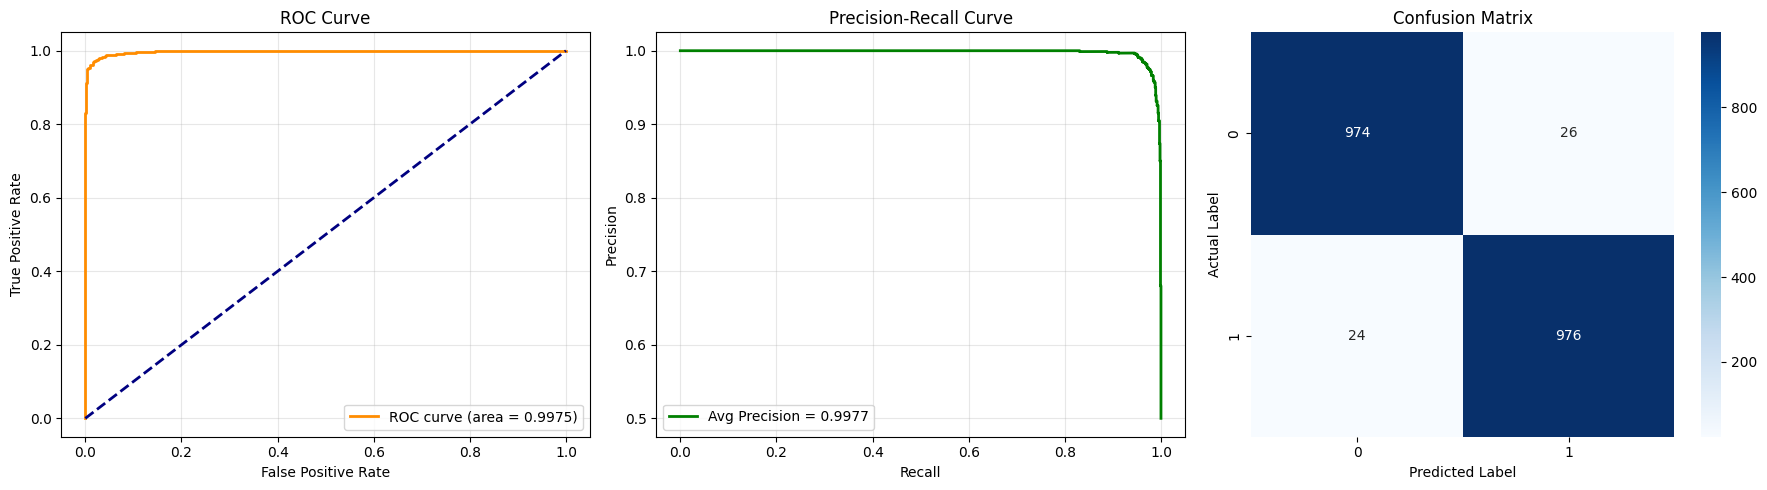

In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

exp_id = 'tfidf_logreg'
# Collecting metrics
metrics = {
    "name": "TF-IDF + LogReg",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "AUC-ROC": roc_auc_score(y_test, y_prob)
}

# Saving results for the final comparison report
with open(OUTPUT_METRICS, 'w') as f:
    json.dump(metrics, f, indent=4)

np.save(os.path.join(OUTPUT_DIR, f'y_prob_{exp_id}.npy'), y_prob)
np.save(os.path.join(OUTPUT_DIR, f'y_true_{exp_id}.npy'), y_test)

# Print Summary Table
print("-" * 35)
print(f"{'Metric':<15} | {'Value':<10}")
print("-" * 35)
for k, v in metrics.items():
    if k != "name":
        print(f"{k:<15} | {v:.4f}")
print("-" * 35)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ROC-curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {metrics["AUC-ROC"]:.4f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_title('ROC Curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_p = average_precision_score(y_test, y_prob)
ax[1].step(recall, precision, where='post', color='green', lw=2, label=f'Avg Precision = {avg_p:.4f}')
ax[1].set_title('Precision-Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[2])
ax[2].set_title('Confusion Matrix')
ax[2].set_ylabel('Actual Label')
ax[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### Final Analysis of Experiment #2: Logistic Regression

**1. Performance Evaluation:**
The Logistic Regression model achieved an **Accuracy of 0.9750** and an **AUC-ROC of 0.9975**. These metrics are remarkably high for a linear classifier, nearly matching the performance of the Random Forest model. 

**2. Key Findings:**
* **Linear Separability:** Since a linear model performs as well as a complex ensemble of trees, it confirms that the "Human" and "AI" classes in this dataset are linearly separable in the TF-IDF feature space.
* **Lexical Predictability:** The model relies heavily on high-frequency tokens and stylistic "crutches" common in AI-generated text.

**3. Strategic Conclusion for the Thesis:**
While these results are impressive, they highlight a potential weakness in lexical-only detection: the model is "learning the topic" rather than "learning the syntax." To achieve a truly robust system that cannot be bypassed by simple paraphrasing, we must move to **Stylometric Analysis**.